In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv("../student_data_categorized.csv")

In [3]:
df_raw.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target
0,Single,17,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,15,1,Tourism,Daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1,5,Communication Design,Daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,17,2,Journalism and Communication,Daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,39,1,Social Service (evening attendance),Evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital status                  4424 non-null   str    
 1   Application mode                4424 non-null   int64  
 2   Application order               4424 non-null   int64  
 3   Course                          4424 non-null   str    
 4   Daytime/evening attendance      4424 non-null   str    
 5   Previous qualification          4424 non-null   str    
 6   Previous qualification (grade)  4424 non-null   float64
 7   Nacionality                     4424 non-null   str    
 8   Mother's qualification          4424 non-null   str    
 9   Father's qualification          4424 non-null   str    
 10  Mother's occupation             4424 non-null   str    
 11  Father's occupation             4424 non-null   str    
 12  Admission grade                 4424 non-null

The dataset contains 4,424 student records and 37 variables. Each row represents an individual student, while each column represents a demographic, educational, or academic characteristic. The dataset contains no missing values, as all variables have 4,424 non-null observations. Variables include student demographics, parental background, admission information, academic performance, and final enrollment outcomes.

In [5]:
for column in df_raw.columns:
    print(column)

Marital status
Application mode
Application order
Course
Daytime/evening attendance
Previous qualification
Previous qualification (grade)
Nacionality
Mother's qualification
Father's qualification
Mother's occupation
Father's occupation
Admission grade
Displaced
Educational special needs
Debtor
Tuition fees up to date
Gender
Scholarship holder
Age at enrollment
International
1st_sem_credited
1st_sem_enrolled
1st_sem_evaluations
1st_sem_approved
1st_sem_grade
1st_sem_without_eval
2nd_sem_credited
2nd_sem_enrolled
2nd_sem_evaluations
2nd_sem_approved
2nd_sem_grade
2nd_sem_without_eval
Unemployment rate
Inflation rate
GDP
Target


Main Question #3: What subgroup of students are the most likely to drop out?

Guiding Questions: 
1. Does the age of enrollment correlate with the likelihood of dropping out?
2. How does marital status and gender influence the dropout rate?
3. How do parental education levels affect the probability of dropping out?
4. Does the number of curriculum units a student fails to evaluate, serve as an early warning sign for dropping out? 

Guiding Question #1: - Does age at enrollment correlate with student dropout? 


In [6]:
df_raw.groupby("Target")["Age at enrollment"].describe()

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Dropout,1421.0,26.068966,8.704024,18.0,19.0,23.0,30.0,70.0
Enrolled,794.0,22.369018,6.302672,17.0,19.0,20.0,23.0,54.0
Graduate,2209.0,21.783612,6.693218,17.0,18.0,19.0,21.0,62.0


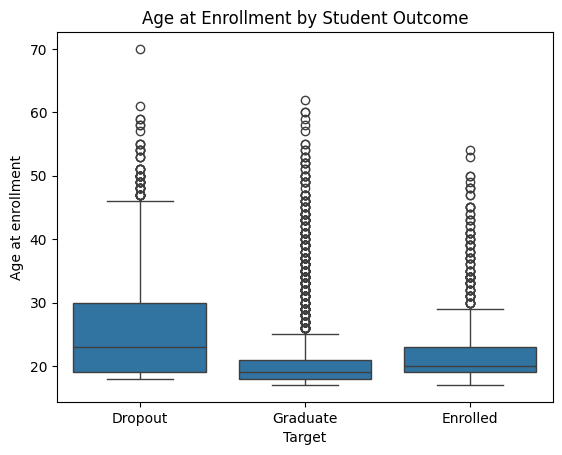

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="Target",
    y="Age at enrollment",
    data = df_raw
)

plt.title("Age at Enrollment by Student Outcome")
plt.show()

It is evident from the boxplot that the students who have discontinued their studies usually joined them at an older age than those students who successfully completed their education. It is clear from the fact that the median age for dropouts is significantly higher than for graduates, which indicates that there could be a link between the age at which the students joined their studies and how well they fared. Furthermore, the variability for the dropout category was also higher as shown by the wider range for the box and whisker. However, there are older students in all categories.

Guiding Question 2 : How do gender and marital status influence student outcomes? 

In [8]:
df_raw["Gender Label"] = df_raw["Gender"].map({
    0: "Male",
    1: "Female",
})

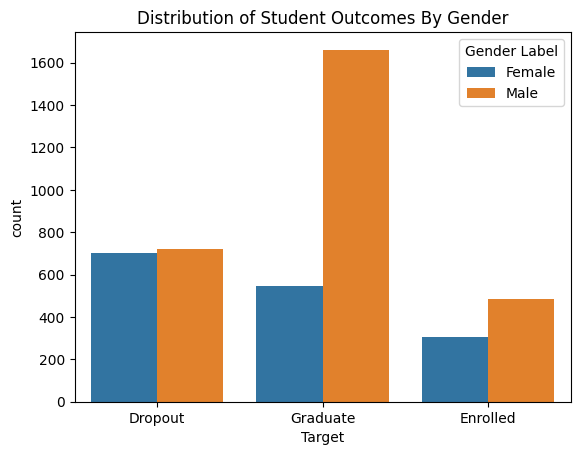

In [9]:
sns.countplot (
    x = 'Target',
    hue = 'Gender Label',
    data = df_raw
    
)

plt.title("Distribution of Student Outcomes By Gender")
plt.show()

In [11]:
df_raw["Marital status"].value_counts()

Marital status
Single               3919
Married               379
Divorced               91
Facto Union            25
Legally Separated       6
Widower                 4
Name: count, dtype: int64

In [13]:
pd.crosstab(
    df_raw["Marital status"],
    df_raw["Target"],
    normalize = "index"
) * 100

Target,Dropout,Enrolled,Graduate
Marital status,,,
Divorced,46.153846,17.582418,36.263736
Facto Union,44.000000,12.000000,44.000000
Legally Separated,66.666667,16.666667,16.666667
Married,47.229551,13.720317,39.050132
Single,30.211789,18.372034,51.416178
Widower,25.000000,50.000000,25.000000


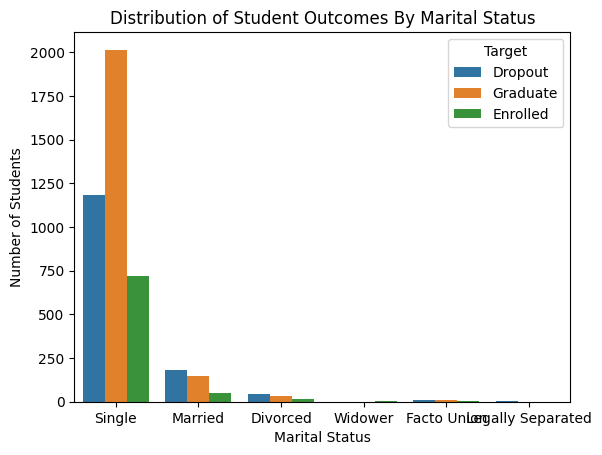

In [16]:
sns.countplot(
    x = "Marital status",
    hue = "Target",
    data = df_raw

)

plt.title("Distribution of Student Outcomes By Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Students")
plt.show()